# 5. Tidal heating basics

An eccentric or non-synchronously-rotating world is flexed by its host's tide, and the internal
friction of that flexing dissipates orbital and rotational energy as heat. To compute it, you attach a
**tide model** to a world and call `calc_tides` with the orbital and spin state.

The simplest tide models are analytic. The **constant phase lag** (fixed-Q) model writes the tidal
response as a Love number `k` with a fixed lag set by a quality factor `Q`. It needs no interior
detail, which makes it a good first look at how tidal heating depends on the orbit. Here we apply it to
Io and see how the heating scales with eccentricity and with `Q`. Interior rheology, which makes `k`
and the lag depend on frequency, comes in the next notebook.


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G
from TidalPy.structures_x.configs import build_world
from TidalPy.Tides_x.classes import make_tide

# A simple Io: an iron core under a rocky mantle.
io_config = {
    "schema_version": "0.2.0", "name": "Io", "type": "terrestrial",
    "radius_m": 1.8216e6, "mass_kg": 8.9319e22, "spin_frequency_rad_s": 4.11e-5,
    "layers": {
        "core":   {"class": "physics", "type": "iron", "layer_index": 0,
                   "radius_outer_m": 9.0e5, "is_tidal": False},
        "mantle": {"class": "solidliquid", "type": "mantle_rock", "layer_index": 1,
                   "radius_fraction": 1.0, "is_tidal": True},
    },
}
io = build_world(io_config)

# Jupiter as the tidal host and Io's orbit.
M_JUP = 1.898e27
A_IO = 4.217e8            # semi-major axis, meters
E_IO = 0.0041            # present-day forced eccentricity
n = np.sqrt(G * M_JUP / A_IO**3)   # mean motion; Io rotates synchronously
print(f"Io mean motion: {n:.4e} rad/s   (period {2*np.pi/n/86400:.2f} days)")


Io mean motion: 4.1100e-05 rad/s   (period 1.77 days)


## Attaching a fixed-Q tide and computing the heating

We build a fixed-Q model with a Love number `k2` and quality factor `Q`, attach it, set the tidal harmonic configuration, and call `calc_tides`. The fixed-`k`/`Q` values are per tidal degree, given as lists indexed from degree l=2.

In [2]:
tide = make_tide("fixed_q", {"fixed_k": [0.3], "fixed_q": [100.0]})
io.set_tide_model(tide)
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
io.set_spin_frequency(n)   # synchronous rotation

io.calc_tides(orbital_frequency=n, spin_frequency=n, eccentricity=E_IO,
              obliquity=0.0, semi_major_axis=A_IO, host_mass=M_JUP)

heating = io.get_tidal_heating()
surface_flux = heating / io.calc_surface_area(io.radius)
print(f"total tidal heating : {heating:.3e} W")
print(f"surface heat flux   : {surface_flux:.2f} W/m^2")
print("(Io's observed output is about 1e14 W, or roughly 2 W/m^2, depending on k2 and Q.)")


total tidal heating : 1.866e+13 W
surface heat flux   : 0.45 W/m^2
(Io's observed output is about 1e14 W, or roughly 2 W/m^2, depending on k2 and Q.)


## Dependence on eccentricity

Tidal heating is driven by the changing distance and rate over an eccentric orbit. To leading order it grows as the square of the eccentricity. Sweeping across the range Io's eccentricity is thought to have occupied (about 0.004 to 0.03, Hussmann & Spohn 2004) shows the clean quadratic slope.

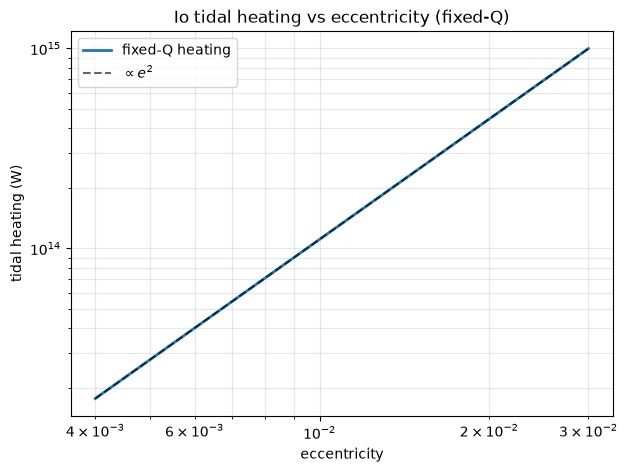

In [3]:
eccs = np.linspace(0.004, 0.03, 60)
heat = []
for e in eccs:
    io.calc_tides(n, n, e, 0.0, A_IO, M_JUP)
    heat.append(io.get_tidal_heating())
heat = np.array(heat)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(eccs, heat, lw=2, label="fixed-Q heating")
ax.loglog(eccs, heat[0] * (eccs / eccs[0])**2, "k--", alpha=0.6, label=r"$\propto e^2$")
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title("Io tidal heating vs eccentricity (fixed-Q)")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()


## Dependence on the quality factor

The quality factor `Q` measures how lossy the body is: a smaller `Q` means more dissipation per cycle and thus more heating, with the heating inversely proportional to `Q`. Three values bracket the plausible range.

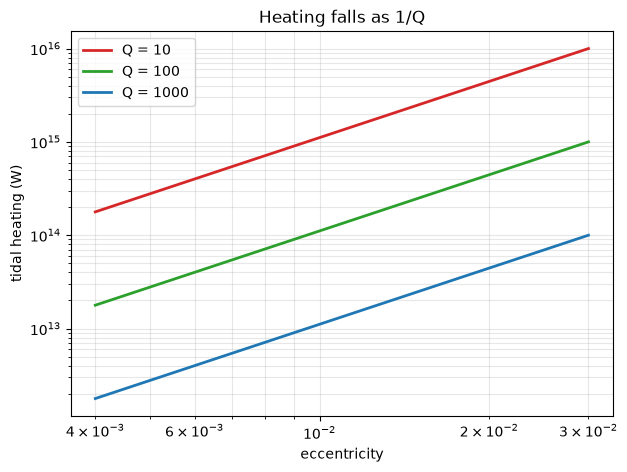

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for q, color in [(10.0, "tab:red"), (100.0, "tab:green"), (1000.0, "tab:blue")]:
    io.set_tide_model(make_tide("fixed_q", {"fixed_k": [0.3], "fixed_q": [q]}))
    io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=2, obliquity_truncation=0)
    heat = []
    for e in eccs:
        io.calc_tides(n, n, e, 0.0, A_IO, M_JUP)
        heat.append(io.get_tidal_heating())
    ax.loglog(eccs, heat, color=color, lw=2, label=f"Q = {q:.0f}")
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title("Heating falls as 1/Q")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.show()


## Recap

- Attach a tide model with `set_tide_model`, set the harmonic range with `set_tide_config`, then call
  `calc_tides` with the orbital and spin state; `get_tidal_heating` returns the total in watts.
- The fixed-Q model is analytic: heating grows as roughly `e^2` and falls as `1/Q`.
- A single world can be re-used across a parameter sweep by calling `calc_tides` again, or swapped to a
  new tide model with another `set_tide_model`, without rebuilding it.

Next: **`06_rheology_io`** replaces the fixed lag with a real interior rheology, where the response
depends on the material's shear modulus and viscosity.
